In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [62]:
df = pd.read_csv(r"car data.csv")

## EDA & Cleaning

In [63]:
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [64]:
df.shape

(301, 9)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [66]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [67]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [68]:
df.duplicated().sum()

np.int64(2)

In [69]:
df.drop_duplicates(inplace = True)

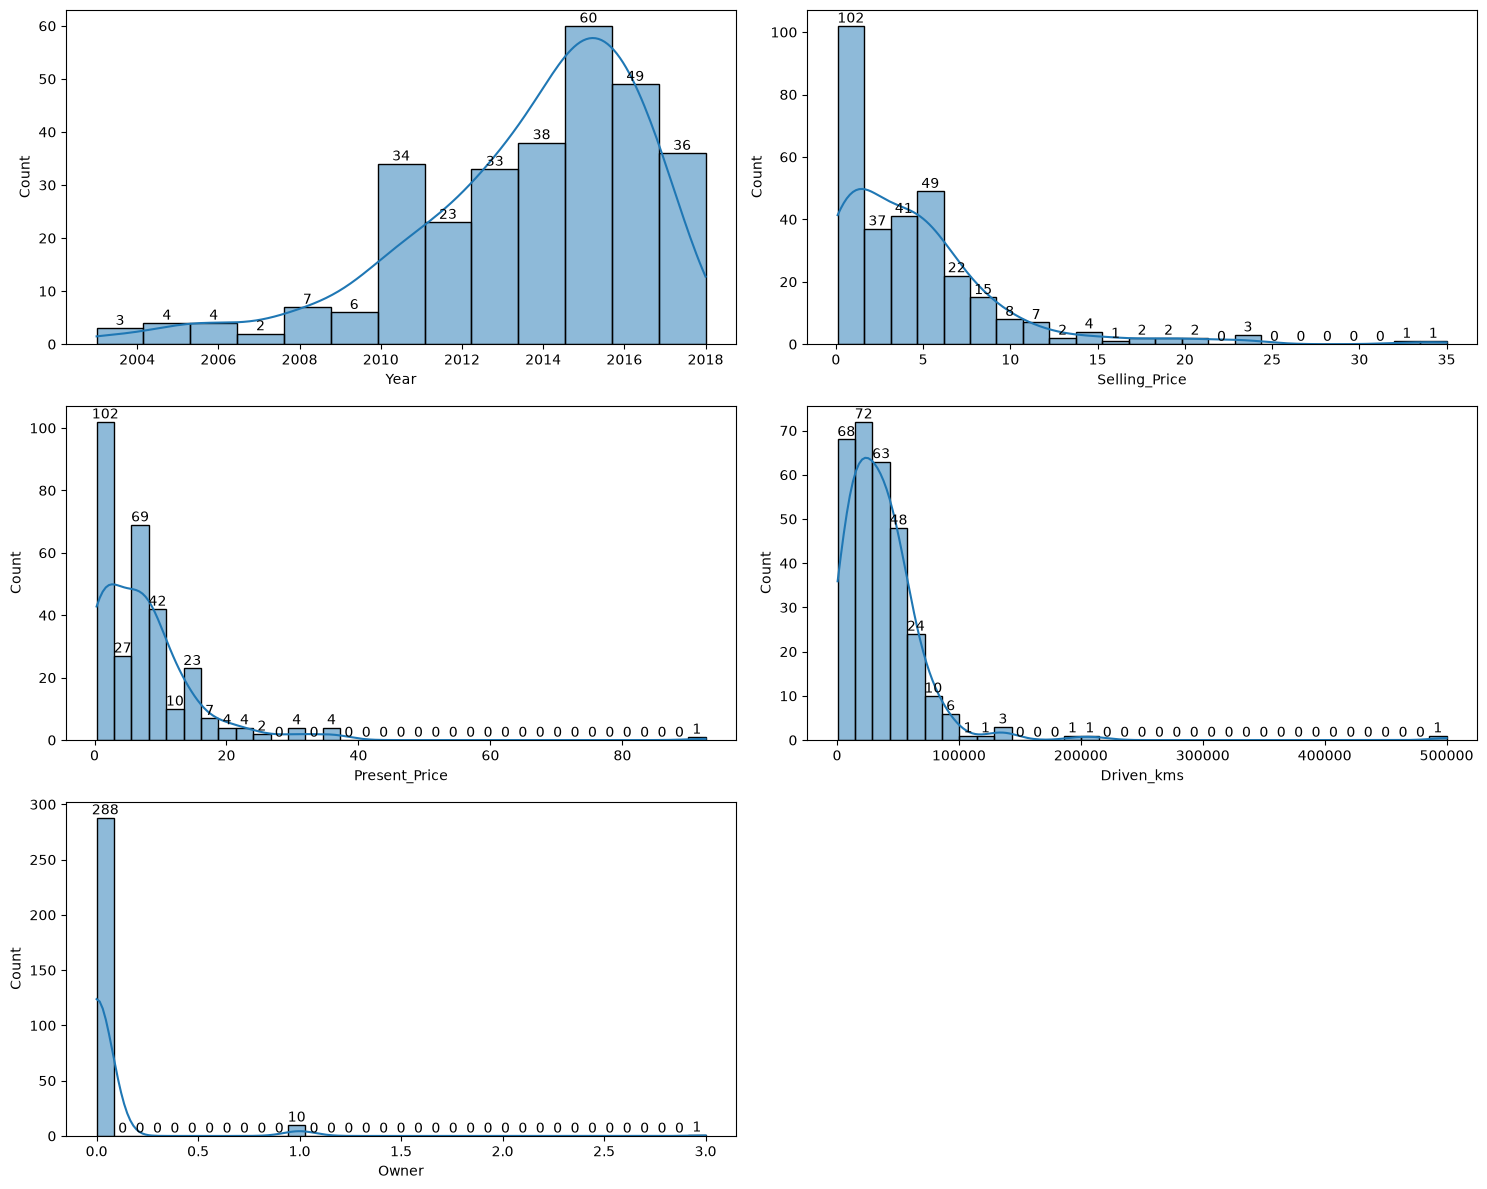

In [70]:
fig, axes = plt.subplots(3, 2, figsize = (15, 12))
axes = axes.flatten()

columns = df.select_dtypes([int, float]).columns

for i, col in enumerate(columns):
    sns.histplot(
        df[col],
        kde = True,
        ax = axes[i]
    )

    for container in axes[i].containers:
        axes[i].bar_label(container)

axes[5].remove()   
plt.tight_layout()
plt.show()

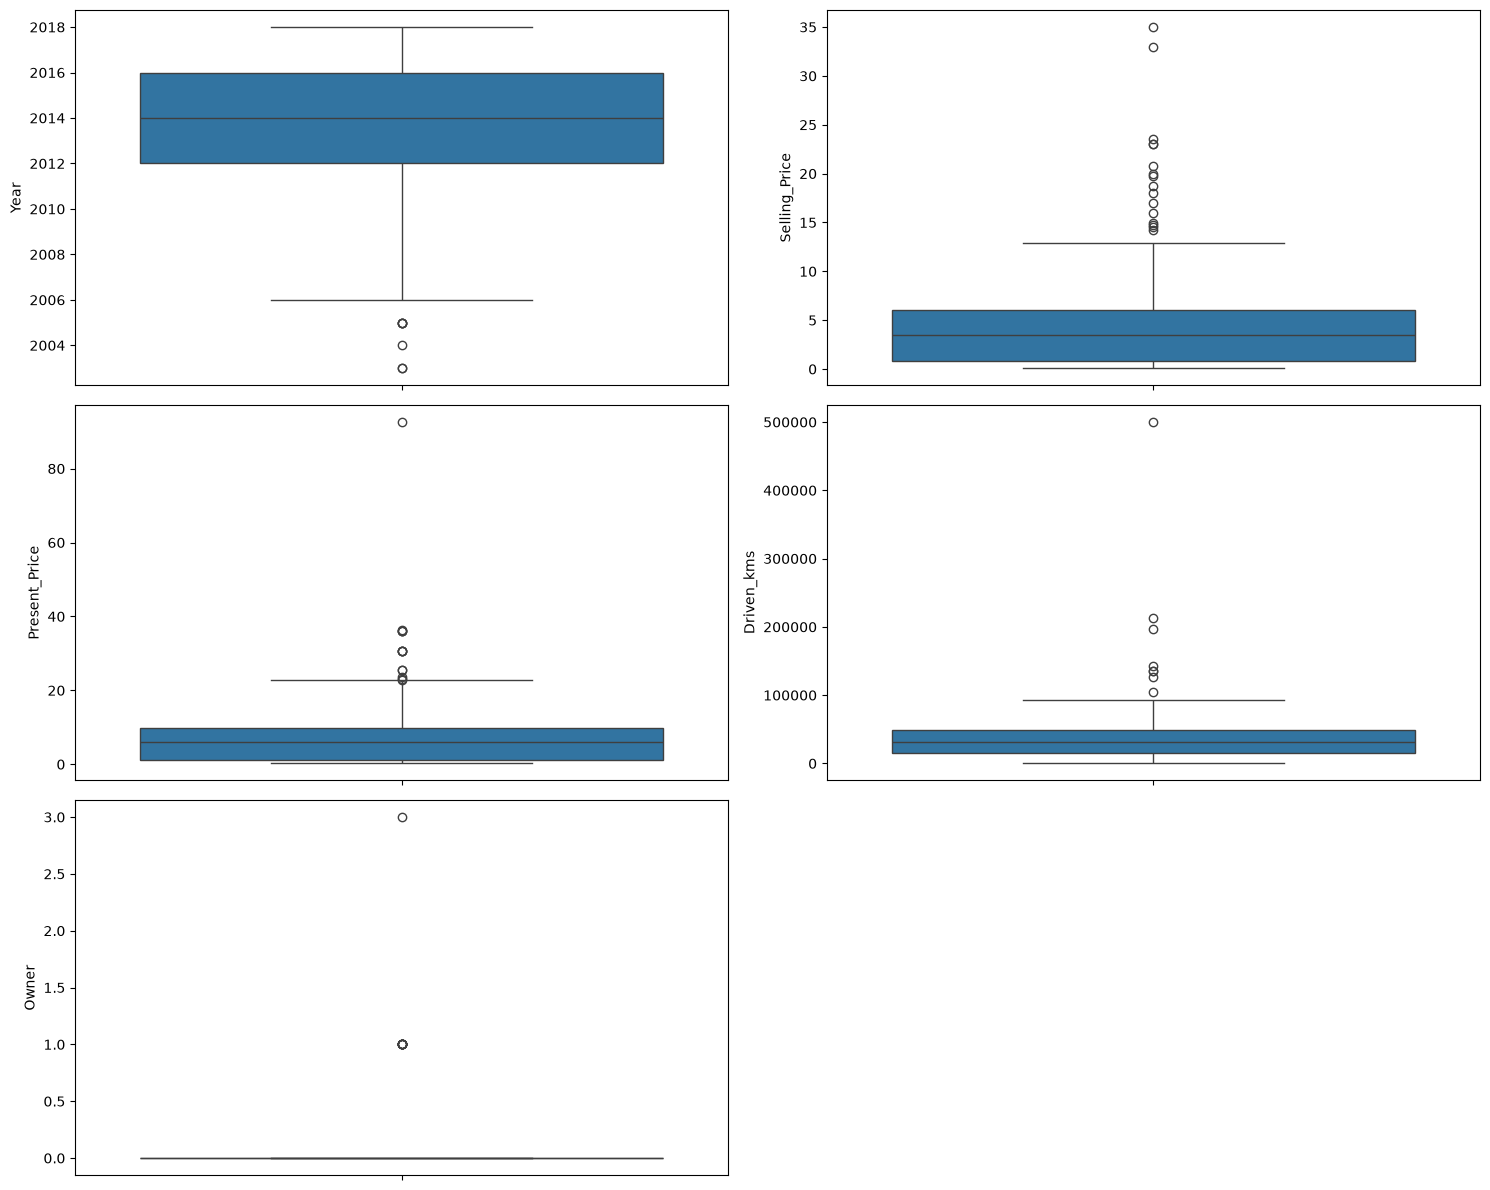

In [71]:
fig, axes = plt.subplots(3, 2, figsize = (15, 12))
axes = axes.flatten()

columns = df.select_dtypes([int, float]).columns

for i, col in enumerate(columns):
    sns.boxplot(
        df[col],
        ax = axes[i]
    )

axes[5].remove()   
plt.tight_layout()
plt.show()

In [72]:
df.corr(numeric_only = True)

,Year,Selling_Price,Present_Price,Driven_kms,Owner
Year,1.000000,0.234369,-0.053167,-0.525714,-0.181639
Selling_Price,0.234369,1.000000,0.876305,0.028566,-0.087880
Present_Price,-0.053167,0.876305,1.000000,0.205224,0.009948
Driven_kms,-0.525714,0.028566,0.205224,1.000000,0.089367
Owner,-0.181639,-0.087880,0.009948,0.089367,1.000000


In [73]:
df.drop(columns = ['Owner'], inplace = True)

In [74]:
df.head(3)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual


In [75]:
num_col = ['Year', 'Selling_Price', 'Present_Price', 'Driven_kms']

for i in num_col:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[i] = df[i].clip(lower = lower_bound, upper = upper_bound)

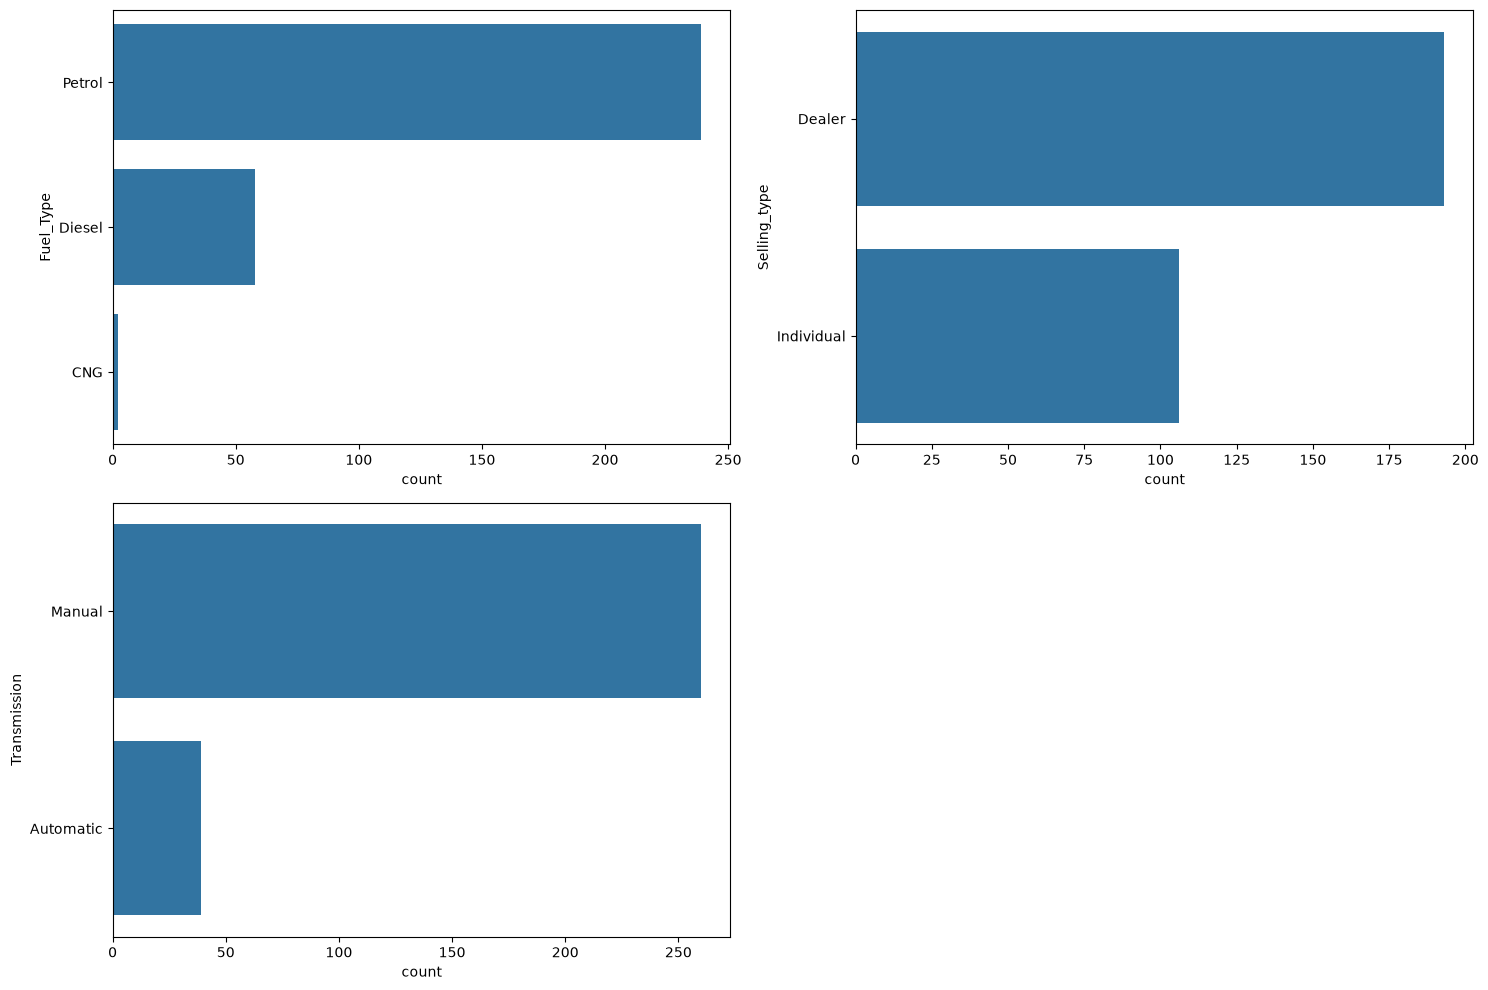

In [76]:
fig, axes = plt.subplots(2, 2, figsize = (15, 10))
axes = axes.flatten()

columns = df.select_dtypes(object).drop(columns = ['Car_Name']).columns

for i, col in enumerate(columns):
    sns.countplot(
        df[col],
        ax = axes[i]
    )

axes[3].remove()   
plt.tight_layout()
plt.show()

In [77]:
df.head(3)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission
0,ritz,2014,3.35,5.59,27000.0,Petrol,Dealer,Manual
1,sx4,2013,4.75,9.54,43000.0,Diesel,Dealer,Manual
2,ciaz,2017,7.25,9.85,6900.0,Petrol,Dealer,Manual


In [78]:
df.head(3)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission
0,ritz,2014,3.35,5.59,27000.0,Petrol,Dealer,Manual
1,sx4,2013,4.75,9.54,43000.0,Diesel,Dealer,Manual
2,ciaz,2017,7.25,9.85,6900.0,Petrol,Dealer,Manual


In [79]:
obj_col = df.select_dtypes(object).columns
for i in obj_col:
    print(f'no of unique in {i} : {df[i].nunique()}'.capitalize())

No of unique in car_name : 98
No of unique in fuel_type : 3
No of unique in selling_type : 2
No of unique in transmission : 2


In [80]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Car_Name'] = le.fit_transform(df['Car_Name'])

In [81]:
df.head(3)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission
0,90,2014,3.35,5.59,27000.0,Petrol,Dealer,Manual
1,93,2013,4.75,9.54,43000.0,Diesel,Dealer,Manual
2,68,2017,7.25,9.85,6900.0,Petrol,Dealer,Manual


In [82]:
df = pd.get_dummies(df, drop_first = True, dtype = int)

In [83]:
df.head(3)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,90,2014,3.35,5.59,27000.0,0,1,0,1
1,93,2013,4.75,9.54,43000.0,1,0,0,1
2,68,2017,7.25,9.85,6900.0,0,1,0,1


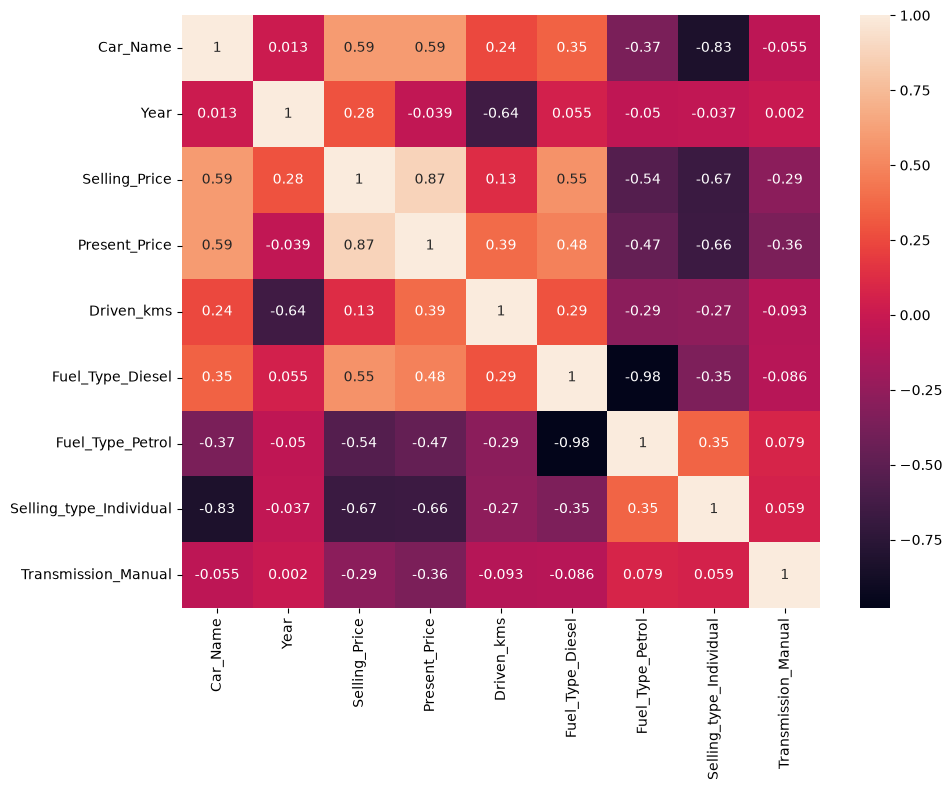

In [84]:
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(numeric_only = True), annot = True)

plt.tight_layout()
plt.show()

## Train Test Split

In [90]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['Present_Price', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual'])
y = df['Present_Price']

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.2, random_state = 42)

## Scaling

In [91]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

## Model Training

In [92]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

## Model Evaluation

In [93]:
from sklearn.metrics import mean_squared_error, r2_score

print(f"R² Score: {r2_score(y_test, y_pred) * 100 :.2f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred)}")

R² Score: 70.03
RMSE: 13.324566796410876


In [94]:
lr.predict([[90, 2014, 3.35, 27000.0, 0]])

array([15208.46486902])